In [12]:
import sys
import os
import json
import fitz  # PyMuPDF
from pathlib import Path
from typing import TypedDict, Optional, Dict, List, Any
from IPython.display import Image, display
from dotenv import load_dotenv
from googleapiclient.discovery import build
# 1. Project Root & Env Setup
root = Path().resolve().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

load_dotenv()
from config import settings
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.graphs import Neo4jGraph
from langchain_community.vectorstores import Neo4jVector
from tavily import TavilyClient

# 2. Initialize Models & Tools
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

class FixedGoogleEmbeddings(GoogleGenerativeAIEmbeddings):
    def embed_query(self, text: str):
        return super().embed_documents([text])[0]

embeddings = FixedGoogleEmbeddings(model="models/gemini-embedding-001", output_dimensionality=768)

graph_db = Neo4jGraph(url=settings.NEO4J_URI, username=settings.NEO4J_USERNAME, password=settings.NEO4J_PASSWORD)

# 3. Built-in Retrievers
vector_retriever = Neo4jVector.from_existing_index(
    embeddings, url=settings.NEO4J_URI, username=settings.NEO4J_USERNAME, 
    password=settings.NEO4J_PASSWORD, index_name="occupation_embeddings", text_node_property="description"
)

def simple_vector_search(query: str):
    res = vector_retriever.similarity_search(query, k=1)
    return res[0].metadata if res else None

def vector_cypher_retriever(occupation_code: str):
    query = """
    MATCH (o:Occupation {code: $code})
    OPTIONAL MATCH (o)-[r:REQUIRES]->(s:Skill)
    OPTIONAL MATCH (o)-[:PERFORMS]->(t:Task)
    RETURN o.title as title, 
           collect(distinct {name: s.name, level: r.level})[0..10] as skills,
           collect(distinct t.statement)[0..5] as tasks
    """
    res = graph_db.query(query, {"code": occupation_code})
    return res[0] if res else None

print("✅ Phase 1: Models, Graph, & External Tools Connected!")

✅ Phase 1: Models, Graph, & External Tools Connected!


In [ ]:
def safe_json_loads(text: str, default: Any):

    text = text.strip()

    try:

        return json.loads(text)

    except Exception:

        # Try to extract JSON object

        if "{" in text and "}" in text:

            try:

                fixed = text[text.index("{"):text.rindex("}") + 1]

                return json.loads(fixed)

            except Exception:

                pass

        

        if "[" in text and "]" in text:

            try:

                fixed = text[text.index("["):text.rindex("]") + 1]

                return json.loads(fixed)

            except Exception:

                pass

    return default



def clean_role(role: Optional[str]) -> Optional[str]:

    if isinstance(role, str):

        role = role.strip().lower()

        return role or None

    return None



def pick_role_for_lookup(state) -> Optional[str]:

    return (

        state.get("current_role")

        or state.get("target_role")

        or (state.get("locator_data") or {}).get("title")

    )



def extract_items_from_tavily(result: Dict[str, Any], limit: int = 4) -> List[Dict[str, str]]:

    items = []

    for row in (result or {}).get("results", [])[:limit]:

        url = row.get("url")

        title = row.get("title") or url

        if url:

            items.append({

                "title": title,

                "url": url,

                "snippet": (row.get("content") or "")[:260]

            })

    return items



def format_link_section(title: str, items: List[Dict[str, str]], empty_msg: str) -> str:

    if not items:

        return "" # If no links, return empty string so it doesn't clutter the LLM prompt

    lines = [f"### {title}"]

    for item in items:

        snippet = item.get("snippet", "").strip()

        if snippet:

            lines.append(f"- [{item['title']}]({item['url']}) — {snippet}")

        else:

            lines.append(f"- [{item['title']}]({item['url']})")

    return "\n".join(lines)



def format_gaps(gaps: List[Dict[str, Any]]) -> str:

    if not gaps:

        return "No major gaps found."

    lines = []

    for g in gaps:

        try:

            val = round(float(g.get('gap', 0)), 1)

            lines.append(f"- {g.get('skill', 'Unknown')} (+{val})")

        except:

            lines.append(f"- {g.get('skill', 'Unknown')}")

    return "\n".join(lines)



def youtube_search(query: str, max_results: int = 3) -> List[Dict[str, str]]:

    api_key = os.getenv("YOUTUBE_API_KEY")

    if api_key:

        try:

            yt = build("youtube", "v3", developerKey=api_key)

            req = yt.search().list(q=query, part="snippet", maxResults=max_results, type="video", safeSearch="moderate")

            res = req.execute()

            out = []

            for item in res.get("items", []):

                vid = item["id"].get("videoId")

                if not vid: continue

                out.append({

                    "title": item["snippet"].get("title", "YouTube video"),

                    "url": f"https://www.youtube.com/watch?v={vid}",

                    "snippet": item["snippet"].get("description", "")[:260],

                })

            if out: return out

        except Exception:

            pass

    tav = tavily_client.search(f"site:youtube.com {query}", search_depth="basic")

    return extract_items_from_tavily(tav, limit=max_results)

In [14]:
class TalentAngelState(TypedDict, total=False):
    retry_count : int
    user_query: str
    resume_path: Optional[str]
    resume_text: Optional[str]
    resume_skills: Optional[List[str]]

    current_role: Optional[str]
    target_role: Optional[str]
    intent: Optional[str]
    needs_clarification: bool

    locator_data: Optional[Dict[str, Any]]
    target_data: Optional[Dict[str, Any]]
    connector_data: Optional[Dict[str, Any]]

    graph_gap_data: Optional[Dict[str, Any]]
    market_research_data: Optional[Dict[str, Any]]
    social_data: Optional[Dict[str, Any]]
    media_data: Optional[Dict[str, Any]]
    academic_data: Optional[Dict[str, Any]]
    project_data: Optional[Dict[str, Any]]

    supervisor_routes: Optional[List[str]]
    final_response: Optional[str]
    critic_feedback: Optional[str]
    next_action: str

In [15]:
EXTRACTION_PROMPT = """
You are an information extraction system.
Return ONLY valid JSON.

Schema:
{
  "current_role": string or null,
  "target_role": string or null,
  "intent": "transition" | "role_info" | "off_topic",
  "needs_clarification": boolean,
  "resume_skills": list of strings
}

CRITICAL RULES:
1. "transition" = User explicitly mentions wanting to become a role, moving to a role, or provides both a current and target role.
2. "role_info" = User just wants info about a single role, or just states their current job without asking to change.
3. If intent is "transition" but "current_role" is completely unknown/null, set "needs_clarification" to true.
"""

def parser_node(state: TalentAngelState):
    print("📄 Parser: Processing resume...")
    pdf_path = state.get("resume_path")
    if pdf_path and os.path.exists(pdf_path):
        import fitz
        doc = fitz.open(pdf_path)
        raw_text = "\n".join(page.get_text() for page in doc)
        return {"resume_text": raw_text}
    return {"resume_text": None}

def role_extractor_node(state: TalentAngelState):
    print("🧠 Role Extractor: Understanding intent...")
    query = state.get("user_query") or ""
    resume = state.get("resume_text") or ""

    existing_current = state.get("current_role")
    existing_target = state.get("target_role")

    try:
        response = llm.invoke(
            EXTRACTION_PROMPT + f'\nQuery: "{query}"\nResume: {resume[:1500]}'
        ).content.strip()
    except Exception:
        response = "{}"

    clean_json = response.replace("```json", "").replace("```", "").strip()
    data = safe_json_loads(clean_json, {})
    
    extracted_current = clean_role(data.get("current_role"))
    extracted_target = clean_role(data.get("target_role"))
    
    
    if extracted_current == "none": extracted_current = None
    if extracted_target == "none": extracted_target = None
    
    
    current_role = extracted_current if extracted_current else existing_current
    target_role = extracted_target if extracted_target else existing_target

    intent = data.get("intent") or "transition"
    
    
    if target_role and target_role != current_role:
        intent = "transition"

  
    if current_role:
        needs_clarification = False
    elif intent == "transition" and not current_role:
        needs_clarification = True
    else:
        needs_clarification = False

    print(f"   -> Extracted Current Role: '{current_role}'")
    print(f"   -> Extracted Target Role: '{target_role}'")
    print(f"   -> Extracted Intent: '{intent}'")
    print(f"   -> Needs Clarification Flag: {needs_clarification}")

    return {
        "current_role": current_role,
        "target_role": target_role,
        "intent": intent,
        "needs_clarification": needs_clarification,
        "resume_skills": data.get("resume_skills", []),
        "next_action": "gatekeeper",
    }


def gatekeeper_node(state: TalentAngelState):
    print("🛡️ Gatekeeper: Validating query...")
    
    
    intent = state.get("intent", "transition")
    needs_clarification = state.get("needs_clarification", False)

    if intent == "off_topic":
        print("   -> Gatekeeper Blocked: Off-topic query.")
        return {
            "final_response": "I can only help with career-related queries.",
            "next_action": "end",
        }

    
    if needs_clarification:
        print("   -> Gatekeeper Blocked: Missing current role.")
        return {
            "final_response": "Please tell me your current profession so I can guide the transition.",
            "next_action": "end",
        }
        
    print("   -> Gatekeeper Passed: Roles are clear.")
    return {"next_action": "locator"}

def locator_node(state: TalentAngelState):
    print("📍 Locator: Finding role in O*NET taxonomy...")
    
    
    role_to_search = state.get("current_role") or state.get("target_role")
    
    if not role_to_search:
        print("   ⚠️ Locator Error: No role found in state.")
        return {
            "final_response": "I need to know your current or target profession to guide you. Could you clarify?",
            "next_action": "end"
        }

    print(f"   -> Searching database for: '{role_to_search}'")

    try:
        # 2. Safely call the vector database
        result = simple_vector_search(role_to_search)
        
        # 3. Validate that the result is actually a dictionary and has the required 'code'
        if not result or not isinstance(result, dict) or "code" not in result:
            raise ValueError("Vector search returned empty or invalid data.")
            
    except Exception as e:
        # 4. Catch any DB crashes or timeouts gracefully
        print(f"   ⚠️ Locator Search Failed: {e}")
        return {
            "final_response": f"I had trouble finding '{role_to_search}' in my career database right now. Could you try describing your role a little differently?",
            "next_action": "end"
        }

    print(f"   -> Successfully matched to O*NET title: '{result.get('title', 'Unknown')}' (Code: {result.get('code')})")

    return {
        "locator_data": result,
        "next_action": "connector"
    }

def connector_node(state: TalentAngelState):
    print("🔗 Connector: Fetching graph data...")
    
    
    locator_data = state.get("locator_data") or {}
    code = locator_data.get("code")
    
    
    if not code:
        print("   ⚠️ Connector Error: No occupation code found to fetch.")
        return {"connector_data": None, "next_action": "supervisor"}

    try:
        data = vector_cypher_retriever(code)
    except Exception as e:
        print(f"   ⚠️ Connector DB Error: {e}")
        data = None

    if not data:
        return {"connector_data": None, "next_action": "supervisor"}

    
    skills = data.get("skills", [])
    data["skills"] = [s for s in skills if s and isinstance(s, dict) and s.get("name")]

    return {"connector_data": data, "next_action": "supervisor"}

def supervisor_node(state: TalentAngelState):
    print("👔 Supervisor: Air Traffic Controller analyzing semantics...")

    query = state.get("user_query") or ""
    intent = state.get("intent") or "transition"
    has_target = bool(state.get("target_role"))

    prompt = f"""
    You are the Routing Brain of an AI Career Agent.
    User Query: "{query}"
    Detected Intent: "{intent}"

    Decide which workers to trigger based on the MEANING of the user's query.
    1. "pathfinder": Skill gaps. (REQUIRED for transitions).
    2. "market_researcher": Salary, compensation, demand.
    3. "social_scout": Networking, mentors, LinkedIn, Reddit.
    4. "media_expert": Day-in-the-life, videos.
    5. "academic_advisor": Courses, learning, certs.
    6. "project_architect": Portfolios, projects.

    ROUTING RULES:
    - Broad Request: For "roadmap", "plan", or "guide", return ALL 6 workers.
    - Laser Focus: If they ask about one specific thing (e.g., "what courses?"), return ONLY that worker.
    - Transition Rule: If intent is "transition", you MUST ALWAYS include "pathfinder".

    Return ONLY a raw JSON array of strings. Example: ["pathfinder", "market_researcher"]
    """

    try:
        raw_response = llm.invoke(prompt).content.strip()
        clean_json = raw_response.replace("```json", "").replace("```", "").strip()
        routes = safe_json_loads(clean_json, [])
        if not isinstance(routes, list): routes = []
    except Exception as e:
        print(f"   ⚠️ Semantic Routing failed ({e}).")
        routes = []

    # Enforce pathfinder for transitions with a target
    if intent == "transition" and has_target and "pathfinder" not in routes:
        routes.append("pathfinder")

    # Remove pathfinder if there's no target role to compare to
    if not has_target and "pathfinder" in routes:
        routes.remove("pathfinder")
        
    if not routes:
        routes = ["market_researcher", "academic_advisor"]

    routes = sorted(list(set(routes)))
    print(f"   -> 🚀 Semantic Fan-Out Decision: Parallel Routing to {routes}")
    return {"supervisor_routes": routes, "next_action": "dispatch"}



In [ ]:
def pathfinder_node(state: TalentAngelState):
    print("🛤️ Pathfinder [PARALLEL EXECUTION]: Computing skill gaps...")
    
    
    current = state.get("locator_data") or {}
    target_role = state.get("target_role")
    intent = state.get("intent")

    
    if not current.get("code") or intent != "transition" or not target_role:
        return {"graph_gap_data": None, "target_data": None}

    context_prompt = f"""
    Current Role: {current.get('title')}
    Target Role: {target_role}
    
    We need to search an occupational database (O*NET). Sometimes job titles are ambiguous.
    Based on the industry of the Current Role, rewrite the Target Role into a highly specific, industry-accurate search term.
    Return ONLY the specific search term string. No quotes, no markdown, no explanation.
    """
    
    try:
        raw_search = llm.invoke(context_prompt).content.strip()
        
        search_query = raw_search.replace("```text", "").replace("```", "").replace("\n", "").strip()
    except Exception:
        search_query = target_role
        
    print(f"   -> Refined Database Search Term: '{search_query}'")
    
    try:
        target_job = simple_vector_search(search_query)
    except Exception as e:
        print(f"   ⚠️ Pathfinder Vector Search Error: {e}")
        target_job = None
    
    if not target_job or "code" not in target_job:
        return {"graph_gap_data": None, "target_data": None}

    gap_query = """
    MATCH (target:Occupation {code: $target_code})-[r_target:REQUIRES]->(s:Skill)
    OPTIONAL MATCH (current:Occupation {code: $current_code})-[r_current:REQUIRES]->(s)
    WITH s, COALESCE(r_target.level, 0) AS t, COALESCE(r_current.level, 0) AS c
    WHERE t > c AND s.name IS NOT NULL
    RETURN s.name AS skill, c AS current_level, t AS target_level, (t - c) AS gap
    ORDER BY gap DESC LIMIT 8
    """
    
    
    try:
        gap_data = graph_db.query(
            gap_query,
            {"current_code": current["code"], "target_code": target_job["code"]},
        )
       
        clean_gaps = [g for g in gap_data if isinstance(g, dict) and g.get("skill")]
    except Exception as e:
        print(f"   ⚠️ Pathfinder Neo4j Error: {e}")
        clean_gaps = []
    
    print(f"   -> Found {len(clean_gaps)} critical skill gaps.")

    return {
        "target_data": target_job,
        "graph_gap_data": {
            "current_role": current.get("title", "Unknown"),
            "target_role": target_job.get("title", "Unknown"),
            "gaps": clean_gaps,
        },
    }

def market_researcher_node(state: TalentAngelState):
    print("📈 Market Researcher [PARALLEL EXECUTION]: Fetching live salary and demand...")
   
    role = state.get("target_role") or state.get("current_role") or "the role"
    query = f"Average salary and hiring market demand in India for {role}"
    
    try:
        # 2. Call the API
        result = tavily_client.search(query, search_depth="basic")
        
        
        if not isinstance(result, dict):
            raise ValueError(f"Tavily returned an invalid format: {type(result)}")
            
        results_list = result.get("results", [])
        
        
        links = [
            {
                "title": r.get("title", "Market Link"), 
                "url": r.get("url", "#"), 
                "snippet": r.get("content", "")
            } 
            for r in results_list[:4] if isinstance(r, dict)
        ]
        
        snippet_text = "\n".join([r.get("content", "") for r in results_list[:2] if isinstance(r, dict)])
        
    except Exception as e:
        
        print(f"   ⚠️ Market Researcher API Error: {e}")
        links = []
        snippet_text = ""

    
    if not snippet_text:
        snippet_text = f"Could not extract a clean salary snippet for {role}."

    return {
        "market_research_data": {
            "role": role,
            "summary": snippet_text[:700],
            "links": links,
        }
    }


def social_scout_node(state: TalentAngelState):
    print("🌐 Social Scout [PARALLEL EXECUTION]: Scraping networking links...")
    
    # Safely get the role
    role = state.get("target_role") or state.get("current_role") or "the role"

    
    query = f"site:reddit.com OR site:linkedin.com career networking advice for {role}"
    
    try:
        result = tavily_client.search(query, search_depth="basic")
        
        
        if not isinstance(result, dict):
            raise ValueError(f"Tavily returned an invalid format: {type(result)}")
            
        results_list = result.get("results", [])
        
        links = [
            {
                "title": r.get("title", "Networking Link"), 
                "url": r.get("url", "#")
            } 
            for r in results_list[:4] if isinstance(r, dict)
        ]
        
    except Exception as e:
        
        print(f"   ⚠️ Social Scout API Error: {e}")
        links = []

    tips = [
        f"Join '{role}' specific LinkedIn groups and comment on posts regularly.",
        "Search for Reddit threads about day-to-day work and interview prep.",
        "Ask one clear question in each outreach message."
    ]

    return {
        "social_data": {
            "role": role,
            "tips": tips,
            "links": links,
        }
    }






In [ ]:
def media_expert_node(state: TalentAngelState):
    print("🎥 Media Expert [PARALLEL EXECUTION]: Sourcing relevant YouTube videos...")
    role = state.get("target_role") or state.get("current_role") or "the role"

   
    try:
        videos = youtube_search(f"day in the life of a {role}", max_results=3)
        
        if not isinstance(videos, list):
            videos = []
    except Exception as e:
        print(f"   ⚠️ Media Expert API Error: {e}")
        videos = []
        
    return {
        "media_data": {
            "role": role,
            "videos": videos,
        }
    }

def academic_advisor_node(state: TalentAngelState):
    print("🎓 Academic Advisor [PARALLEL EXECUTION]: Searching for best online courses...")
    role = state.get("target_role") or state.get("current_role") or "the role"

    try:
        result = tavily_client.search(f"Best online courses and certifications for {role} Coursera Udemy edX", search_depth="basic")
        
        
        if not isinstance(result, dict):
            raise ValueError(f"Tavily returned invalid format: {type(result)}")
            
        results_list = result.get("results", [])
        
        
        courses = [
            {"title": r.get("title", "Course Link"), "url": r.get("url", "#")} 
            for r in results_list[:4] if isinstance(r, dict)
        ]
        
    except Exception as e:
        
        print(f"   ⚠️ Academic Advisor API Error: {e}")
        courses = []

    return {
        "academic_data": {
            "role": role,
            "courses": courses,
        }
    }

def project_architect_node(state: TalentAngelState):
    print("🏗️ Project Architect [PARALLEL EXECUTION]: Brainstorming portfolio projects...")
    role = state.get("target_role") or state.get("current_role") or "the role"

    prompt = f"""
    Suggest 3 portfolio projects for someone targeting the role of {role}.
    Return ONLY valid JSON with this schema:
    {{
      "projects": [
        {{
          "title": "...",
          "difficulty": "beginner|intermediate|advanced",
          "stack": ["..."],
          "why_it_helps": "...",
          "deliverables": ["..."]
        }}
      ]
    }}
    """
    try:
        raw = llm.invoke(prompt).content
        
        
        clean_json = raw.replace("```json", "").replace("```", "").strip()
        data = safe_json_loads(clean_json, {})
        projects = data.get("projects", [])
        
        
        if not isinstance(projects, list):
            projects = []
            
    except Exception as e:
        
        print(f"   ⚠️ Project Architect LLM Error: {e}")
        projects = []

    
    if not projects:
        projects = [
            {
                "title": f"{role} Portfolio Showcase",
                "difficulty": "intermediate",
                "stack": [role, "Relevant Tools"],
                "why_it_helps": "Demonstrates practical ability and system thinking.",
                "deliverables": ["README", "Live Demo", "Architecture Diagram"],
            }
        ]

    return {
        "project_data": {
            "role": role,
            "projects": projects,
        }
    }

In [ ]:
def data_aggregator_node(state: TalentAngelState):
    print("🔄 Aggregator: Collecting worker outputs...")
    return {"next_action": "consultor"}

def consultor_node(state: TalentAngelState):
    print("👼 Consultor: Building dynamic answer with Formatted Links...")

    current_role = state.get("current_role") or (state.get("locator_data") or {}).get("title") or "your current role"
    target_role = state.get("target_role")
    intent = state.get("intent") or "transition"

    gap_data = state.get("graph_gap_data")
    market = state.get("market_research_data") or {}
    social = state.get("social_data") or {}
    media = state.get("media_data") or {}
    academic = state.get("academic_data") or {}
    projects = state.get("project_data") or {}

    sections = []
    
    if intent == "transition" and target_role:
        sections.append("- Executive summary")
        if gap_data: sections.append("- Skill gaps")
    else:
        sections.append("- Role Overview")

    if market.get("summary") or market.get("links"): sections.append("- Market & Salary Insights")
    if social.get("links"): sections.append("- Networking & Community")
    if media.get("videos"): sections.append("- Day-in-the-Life Videos")
    if academic.get("courses"): sections.append("- Recommended Courses")
    if projects.get("projects"): sections.append("- Portfolio Projects")
    if intent == "transition" and gap_data: sections.append("- 30/60/90 day plan")

    sections_str = "\n".join(sections)

    # ✅ THE FIX: We use your helper functions to build perfect markdown!
    gap_text = format_gaps((gap_data or {}).get("gaps", []))
    market_links = format_link_section("Market Links", market.get("links", []), "")
    social_links = format_link_section("Networking Links", social.get("links", []), "")
    video_links = format_link_section("Video Links", media.get("videos", []), "")
    course_links = format_link_section("Course Links", academic.get("courses", []), "")
    
    project_blocks = []
    for p in projects.get("projects", []):
        stack = ", ".join(p.get("stack", []))
        deliverables = ", ".join(p.get("deliverables", []))
        project_blocks.append(f"- **{p.get('title')}**: Stack: {stack}")
    project_text = "### Portfolio Projects\n" + "\n".join(project_blocks) if project_blocks else ""

    prompt = f"""
You are an expert career strategist.
Generate a response focusing on a transition from **{current_role}** to **{target_role}** (if applicable).

CRITICAL INSTRUCTIONS:
1. Use ONLY the provided data.
2. Structure your response using STRICTLY THESE SECTIONS and NO OTHERS:
{sections_str}
3. If a section is missing from the list above, DO NOT write about it.
4. COPY THE LINKS EXACTLY as they appear in the data below. Keep them as clickable Markdown.
"""

    
    context = f"""
--- DATA FOR YOU TO USE ---
Skill gaps: {gap_text if gap_data else "Not requested/available."}

Market summary: {market.get("summary", "")}
{market_links}

Networking Tips: {chr(10).join('- ' + t for t in social.get("tips", [])) if social.get("tips") else ""}
{social_links}

{video_links}

{course_links}

{project_text}
"""
    
    retry = state.get("retry_count") or 0
    if state.get("critic_feedback"):
        prompt += f"\n\nReviewer Feedback to Fix: {state['critic_feedback']}"

    final = llm.invoke(prompt + "\n\n" + context).content
    
    return {
        "final_response": final,
        "next_action": "critic",
        "retry_count": retry
    }

def critic_node(state: TalentAngelState):
    print("🧐 Critic: Enforcing Link Integrity...")

    draft = state.get("final_response") or ""
    retry = state.get("retry_count") or 0

    if retry >= 2:
        print("   ✅ Max retries reached → forcing exit")
        return {"next_action": "end", "critic_feedback": None, "retry_count": retry}

    prompt = f"""
Evaluate the response STRICTLY on:
1. Correct role
2. No hallucination
3. Contains links if expected (CRITICAL)
4. Proper structure

Return ONLY JSON:
{{
  "score": number (0-10),
  "feedback": "short reason"
}}

Response:
{draft}
"""

    try:
        raw = llm.invoke(prompt).content.strip()
        clean_json = raw.replace("```json", "").replace("```", "").strip()
        data = safe_json_loads(clean_json, {})
        score = int(data.get("score", 8))
        feedback = data.get("feedback", "Looks good")
    except Exception as e:
        print(f"   ⚠️ Critic parsing failed: {e}")
        return {"next_action": "end", "retry_count": retry}

    print(f"   → Score: {score} | Retry: {retry}")

    if score < 7:
        return {"critic_feedback": feedback, "next_action": "consultor", "retry_count": retry + 1}

    return {"next_action": "end", "critic_feedback": None, "retry_count": retry}

In [19]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(TalentAngelState)

workflow.add_node("parser", parser_node)
workflow.add_node("role_extractor", role_extractor_node)
workflow.add_node("gatekeeper", gatekeeper_node)
workflow.add_node("locator", locator_node)
workflow.add_node("connector", connector_node)
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("pathfinder", pathfinder_node)
workflow.add_node("market_researcher", market_researcher_node)
workflow.add_node("social_scout", social_scout_node)
workflow.add_node("media_expert", media_expert_node)
workflow.add_node("academic_advisor", academic_advisor_node)
workflow.add_node("project_architect", project_architect_node)
workflow.add_node("data_aggregator", data_aggregator_node)
workflow.add_node("consultor", consultor_node)
workflow.add_node("critic", critic_node)

workflow.set_entry_point("parser")

def route_standard(state):
    return state["next_action"]

workflow.add_edge("parser", "role_extractor")
workflow.add_edge("role_extractor", "gatekeeper")
workflow.add_conditional_edges("gatekeeper", route_standard, {"locator": "locator", "end": END})
workflow.add_edge("locator", "connector")
workflow.add_edge("connector", "supervisor")


def route_from_supervisor(state):
    return state.get("supervisor_routes", ["pathfinder"])

possible_workers = [
    "pathfinder",
    "market_researcher",
    "social_scout",
    "media_expert",
    "academic_advisor",
    "project_architect",
]

workflow.add_conditional_edges("supervisor", route_from_supervisor, possible_workers)

for worker in possible_workers:
    workflow.add_edge(worker, "data_aggregator")

workflow.add_edge("data_aggregator", "consultor")
workflow.add_edge("consultor", "critic")
workflow.add_conditional_edges("critic", route_standard, {"consultor": "consultor", "end": END})

memory = MemorySaver()
talent_app = workflow.compile(checkpointer=memory)

🎨 Generating V2 Architecture Map...


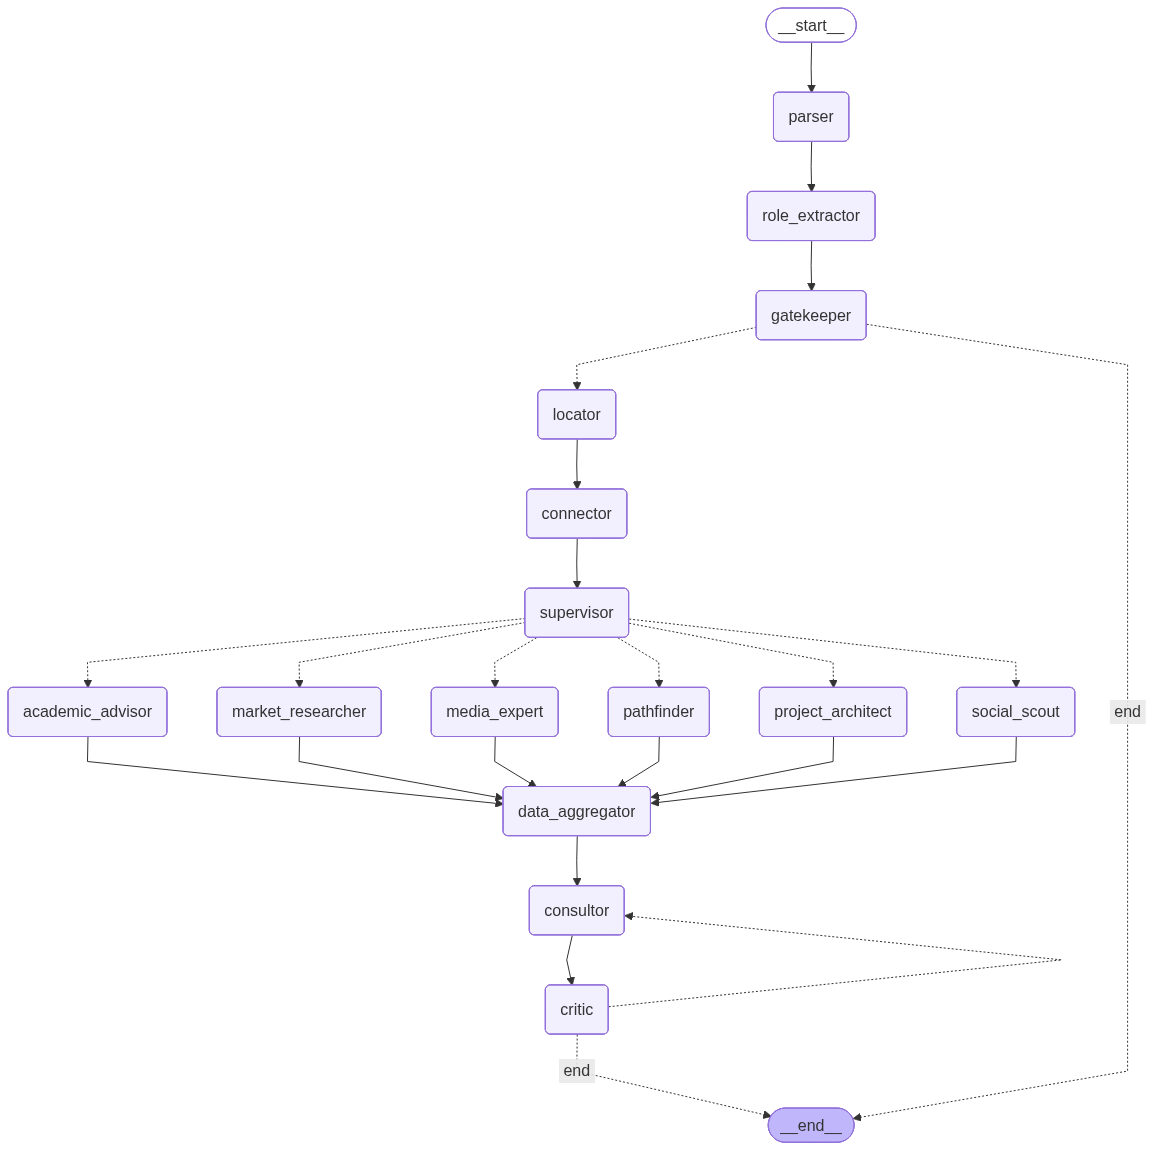


🚀 LAUNCHING V2 FULL PIPELINE TEST


In [20]:
print("🎨 Generating V2 Architecture Map...")
try:
    display(Image(talent_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not fetch image, displaying ASCII...")
    print(talent_app.get_graph().draw_ascii())

print("\n" + "="*50)
print("🚀 LAUNCHING V2 FULL PIPELINE TEST")
print("="*50)



In [10]:
import uuid

# 1. Test the Comprehensive Roadmap
thread_1 = {"configurable": {"thread_id": str(uuid.uuid4())}}
print("\n" + "="*50 + "\n🚀 TEST 1: THE FULL FLEET\n" + "="*50)

response_1 = talent_app.invoke(
    {"user_query": "I am currently a High School Math Teacher and I want to transition into becoming a Data Analyst. Give me a complete roadmap."},
    config=thread_1
)

print("\n--- FINAL OUTPUT ---")
print(response_1["final_response"])


🚀 TEST 1: THE FULL FLEET
📄 Parser: Processing resume...
🧠 Role Extractor: Understanding intent...
   -> Extracted Current Role: 'high school math teacher'
   -> Extracted Target Role: 'data analyst'
   -> Extracted Intent: 'transition'
🛡️ Gatekeeper: Validating query...
📍 Locator: Finding role in O*NET taxonomy...
   -> Searching database for: 'high school math teacher'
   -> Successfully matched to O*NET title: 'Secondary School Teachers, Except Special and Career/Technical Education' (Code: 25-2031.00)
🔗 Connector: Fetching graph data...
👔 Supervisor: Air Traffic Controller analyzing semantics...
   -> 🚀 Semantic Fan-Out Decision: Parallel Routing to ['academic_advisor', 'market_researcher', 'media_expert', 'pathfinder', 'project_architect', 'social_scout']
🎓 Academic Advisor [PARALLEL EXECUTION]: Searching for best online courses...
📈 Market Researcher [PARALLEL EXECUTION]: Fetching live salary and demand...
🛤️ Pathfinder [PARALLEL EXECUTION]: Computing skill gaps...
🎥 Media Expert

In [11]:
# 2. Test the Semantic Router (No keywords used)
thread_2 = {"configurable": {"thread_id": str(uuid.uuid4())}}
print("\n" + "="*50 + "\n🎯 TEST 2: LASER FOCUS\n" + "="*50)

response_2 = talent_app.invoke(
    {"user_query": "I am a Frontend Developer moving to Backend Developer. What is the compensation like in India?"},
    config=thread_2
)

print("\n--- FINAL OUTPUT ---")
print(response_2["final_response"])


🎯 TEST 2: LASER FOCUS
📄 Parser: Processing resume...
🧠 Role Extractor: Understanding intent...
   -> Extracted Current Role: 'frontend developer'
   -> Extracted Target Role: 'backend developer'
   -> Extracted Intent: 'transition'
🛡️ Gatekeeper: Validating query...
📍 Locator: Finding role in O*NET taxonomy...
   -> Searching database for: 'frontend developer'
   -> Successfully matched to O*NET title: 'Web and Digital Interface Designers' (Code: 15-1255.00)
🔗 Connector: Fetching graph data...
👔 Supervisor: Air Traffic Controller analyzing semantics...
   -> 🚀 Semantic Fan-Out Decision: Parallel Routing to ['market_researcher', 'pathfinder']
📈 Market Researcher [PARALLEL EXECUTION]: Fetching live salary and demand...
🛤️ Pathfinder [PARALLEL EXECUTION]: Computing skill gaps...
   -> Refined Database Search Term: 'Web Backend Developer'
   -> Found 8 critical skill gaps.
🔄 Aggregator: Collecting worker outputs...
👼 Consultor: Building dynamic answer with Formatted Links...
🧐 Critic: Enf

In [ ]:

thread_3 = {"configurable": {"thread_id": "memory_test_user_99"}}
print("\n" + "="*50 + "\n🧠 TEST 3: MEMORY & STATE (TURN 1)\n" + "="*50)


response_3a = talent_app.invoke(
    {"user_query": "Hey, I currently work as a Retail Store Manager."},
    config=thread_3
)
print(response_3a["final_response"])  

print("\n" + "="*50 + "\n🧠 TEST 3: MEMORY & STATE (TURN 2)\n" + "="*50)


response_3b = talent_app.invoke(
    {"user_query": "Actually, I want to become a Scrum Master. Can you show me some day in the life videos and certs to get?"},
    config=thread_3
)

print("\n--- FINAL OUTPUT ---")
print(response_3b["final_response"])


🧠 TEST 3: MEMORY & STATE (TURN 1)
📄 Parser: Processing resume...
🧠 Role Extractor: Understanding intent...
   -> Extracted Current Role: 'retail store manager'
   -> Extracted Target Role: 'None'
   -> Extracted Intent: 'role_info'
   -> Needs Clarification Flag: False
🛡️ Gatekeeper: Validating query...
   -> Gatekeeper Passed: Roles are clear.
📍 Locator: Finding role in O*NET taxonomy...
   -> Searching database for: 'retail store manager'
   -> Successfully matched to O*NET title: 'First-Line Supervisors of Retail Sales Workers' (Code: 41-1011.00)
🔗 Connector: Fetching graph data...
👔 Supervisor: Air Traffic Controller analyzing semantics...
   -> 🚀 Semantic Fan-Out Decision: Parallel Routing to ['market_researcher']
📈 Market Researcher [PARALLEL EXECUTION]: Fetching live salary and demand...
🔄 Aggregator: Collecting worker outputs...
👼 Consultor: Building dynamic answer with Formatted Links...
🧐 Critic: Enforcing Link Integrity...
   → Score: 10 | Retry: 0
As an expert career strat

In [ ]:
import fitz  


doc = fitz.open()
page = doc.new_page()


resume_content = """
VISHWAJIT
Current Role: Chief Executive

Experience:
- Led corporate strategy and managed global operations.
- Spearheaded major enterprise negotiations.

Skills:
Leadership, Public Speaking, Corporate Strategy, Budgeting, Curriculum Design
"""


page.insert_text((50, 50), resume_content, fontsize=12)
doc.save("dummy_resume.pdf")
print("📄 dummy_resume.pdf created successfully!")

📄 dummy_resume.pdf created successfully!


In [ ]:
import uuid


thread_4 = {"configurable": {"thread_id": str(uuid.uuid4())}}
print("\n" + "="*50 + "\n🎯 TEST 4: LASER FOCUS (PROJECTS ONLY)\n" + "="*50)

response_4 = talent_app.invoke(
    {"user_query": "I am a Data Analyst. Can you give me some advanced portfolio projects I can build?"},
    config=thread_4
)

print("\n--- FINAL OUTPUT ---")
print(response_4["final_response"])


🎯 TEST 4: LASER FOCUS (PROJECTS ONLY)
📄 Parser: Processing resume...
🧠 Role Extractor: Understanding intent...
   -> Extracted Current Role: 'data analyst'
   -> Extracted Target Role: 'None'
   -> Extracted Intent: 'role_info'
🛡️ Gatekeeper: Validating query...
📍 Locator: Finding role in O*NET taxonomy...
   -> Searching database for: 'data analyst'
   -> Successfully matched to O*NET title: 'Data Scientists' (Code: 15-2051.00)
🔗 Connector: Fetching graph data...
👔 Supervisor: Air Traffic Controller analyzing semantics...
   -> 🚀 Semantic Fan-Out Decision: Parallel Routing to ['project_architect']
🏗️ Project Architect [PARALLEL EXECUTION]: Brainstorming portfolio projects...
🔄 Aggregator: Collecting worker outputs...
👼 Consultor: Building dynamic answer with Formatted Links...
🧐 Critic: Enforcing Link Integrity...
   → Score: 10 | Retry: 0

--- FINAL OUTPUT ---
### Role Overview
As a Data Analyst, your expertise lies in transforming raw data into actionable insights that drive busine